Part III: Improving DQN & Solving Various Problems

In this part, implemented **Double DQN** as an improvement over vanilla DQN from Part II and then apply it to the same three environments (Grid-World, CartPole-v1, MountainCar-v0)
and compare performance.

## 1. Imports and Setup

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque
import random
import os

random.seed(25)
np.random.seed(25)
torch.manual_seed(25)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Environment: WarehouseRobotEnv (Grid-World)
We reuse the same WarehouseRobotEnv from Part II.

In [ ]:
class WarehouseRobotEnv(gym.Env):
    """Warehouse Robot Environment"""
    def __init__(self, stochastic=False, slip_prob=0.1):
      super(WarehouseRobotEnv, self).__init__()
      self.stochastic = stochastic
      self.slip_prob = slip_prob
      self.grid_size = 6
      self.pickup_location = (0, 0)
      self.dropoff_location = (5, 4)
      self.obstacles = [(0, 2), (2, 0), (3, 5), (5, 3)]
      self.action_space = spaces.Discrete(6)
      self.observation_space = spaces.Tuple((
            spaces.Discrete(self.grid_size),
            spaces.Discrete(self.grid_size),
            spaces.Discrete(2)))
      self.agent_pos = None
      self.carrying_item = False
      self.done = False

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        valid_start = False
        while not valid_start:
            self.agent_pos = [np.random.randint(0, self.grid_size), np.random.randint(0, self.grid_size)]
            if tuple(self.agent_pos) not in self.obstacles:
                valid_start = True
        self.carrying_item = False
        self.done = False
        return self._get_observation(), {}

    def step(self, action):
        if self.done:
            return self._get_observation(), 0, True, False, {}
        reward = -1
        old_pos = self.agent_pos.copy()
        if action < 4:
            moved = not self.stochastic or np.random.random() >= self.slip_prob
            if moved:
                if action == 0: self.agent_pos[0] = max(0, self.agent_pos[0] - 1)
                elif action == 1: self.agent_pos[0] = min(self.grid_size - 1, self.agent_pos[0] + 1)
                elif action == 2: self.agent_pos[1] = max(0, self.agent_pos[1] - 1)
                elif action == 3: self.agent_pos[1] = min(self.grid_size - 1, self.agent_pos[1] + 1)
            if tuple(self.agent_pos) in self.obstacles:
                self.agent_pos = old_pos
                reward = -20
        elif action == 4:
            if tuple(self.agent_pos) == self.pickup_location and not self.carrying_item:
                self.carrying_item = True
                reward = 25
        elif action == 5:
            if tuple(self.agent_pos) == self.dropoff_location and self.carrying_item:
                reward = 100
                self.done = True
        return self._get_observation(), reward, self.done, False, {}

    def _get_observation(self):
        return (self.agent_pos[0], self.agent_pos[1], int(self.carrying_item))

    def render(self):
        grid = np.zeros((self.grid_size, self.grid_size))
        for obs in self.obstacles: grid[obs] = 0.3
        grid[self.pickup_location] = 0.6
        grid[self.dropoff_location] = 0.8
        grid[tuple(self.agent_pos)] = 1.0
        plt.figure(figsize=(6, 6))
        plt.imshow(grid, cmap="viridis", interpolation="nearest")
        for i in range(self.grid_size + 1):
            plt.axhline(i - 0.5, color="black", linewidth=1)
            plt.axvline(i - 0.5, color="black", linewidth=1)
        for i in range(self.grid_size):
            for j in range(self.grid_size):
                if (i, j) in self.obstacles:
                    plt.text(j, i, "X", ha="center", va="center", color="white", fontsize=16, fontweight="bold")
                elif (i, j) == self.pickup_location:
                    plt.text(j, i, "P", ha="center", va="center", color="lime", fontsize=16, fontweight="bold")
                elif (i, j) == self.dropoff_location:
                    plt.text(j, i, "D", ha="center", va="center", color="cyan", fontsize=16, fontweight="bold")
                elif (i, j) == tuple(self.agent_pos):
                    sym = "A+" if self.carrying_item else "A"
                    col = "orange" if self.carrying_item else "red"
                    plt.text(j, i, sym, ha="center", va="center", color=col, fontsize=16, fontweight="bold")
        status = "Carrying" if self.carrying_item else "Not Carrying"
        mode = "Stochastic" if self.stochastic else "Deterministic"
        plt.title(f"Warehouse Robot - {mode}\nStatus: {status}", fontsize=12, fontweight="bold")
        plt.xlabel("Column"); plt.ylabel("Row")
        plt.xticks(range(self.grid_size)); plt.yticks(range(self.grid_size))
        plt.tight_layout(); plt.show()

## 3. Double DQN Implementation

The key difference from vanilla DQN is in the `train_step` method:
- **Vanilla DQN**: target = r + gamma * max_a Q_target(s_next, a)
- **Double DQN**: a* = argmax Q_online(s_next, a), then target = r + gamma * Q_target(s_next, a*)


In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards, dtype=np.float32),
        np.array(next_states), np.array(dones, dtype=np.float32))
    def __len__(self):
        return len(self.buffer)

In [4]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [5]:
class DoubleDQNAgent:
    def __init__(self, state_dim, action_dim, hidden_dim=64, lr=1e-4,
                 gamma=0.99, epsilon_start=1.0, epsilon_end=0.01,
                 epsilon_decay=0.995, buffer_size=10000, batch_size=64,
                 target_update_freq=10, tau=None):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.tau = tau
        self.q_network = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_network = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.replay_buffer = ReplayBuffer(buffer_size)
        self.steps_done = 0
        self.episodes_done = 0

    def select_action(self, state, greedy=False):
        if greedy or random.random() > self.epsilon:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                return self.q_network(state_t).argmax(dim=1).item()
        return random.randrange(self.action_dim)

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)

    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        states_t = torch.FloatTensor(states).to(device)
        actions_t = torch.LongTensor(actions).to(device)
        rewards_t = torch.FloatTensor(rewards).to(device)
        next_states_t = torch.FloatTensor(next_states).to(device)
        dones_t = torch.FloatTensor(dones).to(device)
        curr_q = self.q_network(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            # online network picks the best actions
            best_actions = self.q_network(next_states_t).argmax(dim=1)
            # target network evaluates those actions
            next_q = self.target_network(next_states_t).gather(1, best_actions.unsqueeze(1)).squeeze(1)
            target_q = rewards_t + self.gamma * next_q * (1 - dones_t)
        loss = self.loss_fn(curr_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        if self.tau is not None:
            self._soft_update()
        return loss.item()

    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())

    def _soft_update(self):
        for tp, op in zip(self.target_network.parameters(), self.q_network.parameters()):
            tp.data.copy_(self.tau * op.data + (1.0 - self.tau) * tp.data)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

In [ ]:
def state_to_array(obs):
    if isinstance(obs, tuple):
        return np.array(obs, dtype=np.float32)
    return np.array(obs, dtype=np.float32)

def train_dqn(env, agent, num_episodes, max_steps=500, print_every=100,
              state_converter=state_to_array, reward_shaper=None):
    all_rewards, all_losses, all_epsilons = [], [], []
    for ep in range(num_episodes):
        obs, _ = env.reset()
        state = state_converter(obs)
        total_reward = 0
        ep_losses = []
        for step in range(max_steps):
            action = agent.select_action(state)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_state = state_converter(next_obs)
            shaped_reward = reward_shaper(obs, next_obs, reward, done) if reward_shaper else reward
            agent.store_transition(state, action, shaped_reward, next_state, float(done))
            loss = agent.train_step()
            if loss is not None: ep_losses.append(loss)
            total_reward += reward
            state = next_state
            obs = next_obs
            agent.steps_done += 1
            if done: break
        agent.decay_epsilon()
        agent.episodes_done += 1
        if agent.tau is None and agent.episodes_done % agent.target_update_freq == 0:
            agent.update_target_network()
        avg_loss = np.mean(ep_losses) if ep_losses else 0
        all_rewards.append(total_reward)
        all_losses.append(avg_loss)
        all_epsilons.append(agent.epsilon)
        if (ep + 1) % print_every == 0:
            recent_avg = np.mean(all_rewards[-print_every:])
            print(f"Episode {ep+1}/{num_episodes} | Avg Reward (last {print_every}): {recent_avg:.2f} | Eps: {agent.epsilon:.4f} | Loss: {avg_loss:.4f}")
    return all_rewards, all_losses, all_epsilons

def evaluate_dqn(env, agent, num_episodes=10, max_steps=500,
                state_converter=state_to_array, render=False):
    eval_rewards = []
    for ep in range(num_episodes):
        obs, _ = env.reset()
        state = state_converter(obs)
        total_reward = 0
        for step in range(max_steps):
            action = agent.select_action(state, greedy=True)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            if render and ep == 0:
                print(f"Step {step+1}: pos={obs}, action={action}, reward={reward}")
                env.render()
            total_reward += reward
            state = state_converter(next_obs)
            obs = next_obs
            if done: break
        eval_rewards.append(total_reward)
        print(f"Eval Episode {ep+1}: Total Reward = {total_reward}")
    print(f"\nAvg eval reward over {num_episodes} episodes: {np.mean(eval_rewards):.2f}")
    return eval_rewards

In [7]:
def plot_training_results(rewards, losses, epsilons, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(rewards, alpha=0.6, label="Episode Reward")
    window = min(50, len(rewards)//5) if len(rewards) > 10 else 1
    if window > 1:
        sm = np.convolve(rewards, np.ones(window)/window, mode="valid")
        axes[0].plot(range(window-1, len(rewards)), sm, color="red", linewidth=2, label=f"Moving Avg ({window} ep)")
    axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Total Reward")
    axes[0].set_title(f"{title_prefix} - Reward per Episode"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(losses, alpha=0.6, color="orange")
    if window > 1 and len(losses) > window:
        sl = np.convolve(losses, np.ones(window)/window, mode="valid")
        axes[1].plot(range(window-1, len(losses)), sl, color="red", linewidth=2)
    axes[1].set_xlabel("Episode"); axes[1].set_ylabel("Avg Loss")
    axes[1].set_title(f"{title_prefix} - Loss per Episode"); axes[1].grid(True, alpha=0.3)
    axes[2].plot(epsilons, color="green")
    axes[2].set_xlabel("Episode"); axes[2].set_ylabel("Epsilon")
    axes[2].set_title(f"{title_prefix} - Epsilon Decay"); axes[2].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_eval_results(eval_rewards, title_prefix=""):
    plt.figure(figsize=(8, 5))
    plt.bar(range(1, len(eval_rewards)+1), eval_rewards, color="steelblue", alpha=0.7)
    plt.axhline(y=np.mean(eval_rewards), color="red", linestyle="--", label=f"Mean: {np.mean(eval_rewards):.2f}")
    plt.xlabel("Episode"); plt.ylabel("Total Reward")
    plt.title(f"{title_prefix} - Evaluation Rewards (Greedy)"); plt.legend()
    plt.grid(True, alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

def plot_comparison(dqn_rewards, ddqn_rewards, env_name):
    plt.figure(figsize=(12, 6))
    window = min(50, len(dqn_rewards)//5) if len(dqn_rewards) > 10 else 1
    plt.plot(dqn_rewards, alpha=0.15, color="blue")
    plt.plot(ddqn_rewards, alpha=0.15, color="orange")
    if window > 1:
        sm1 = np.convolve(dqn_rewards, np.ones(window)/window, mode="valid")
        sm2 = np.convolve(ddqn_rewards, np.ones(window)/window, mode="valid")
        plt.plot(range(window-1, len(dqn_rewards)), sm1, color="blue", linewidth=2, label="Vanilla DQN")
        plt.plot(range(window-1, len(ddqn_rewards)), sm2, color="orange", linewidth=2, label="Double DQN")
    plt.xlabel("Episode"); plt.ylabel("Total Reward")
    plt.title(f"{env_name} - DQN vs Double DQN (Reward Dynamics)")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 4. Training Double DQN on Grid-World
Using the same hyperparameters as Part II for a fair comparison.

In [8]:
gridworld_env = WarehouseRobotEnv(stochastic=False)
gridworld_ddqn_agent = DoubleDQNAgent(state_dim=3, action_dim=6, hidden_dim=64, lr=5e-4,
    gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.9995,
    buffer_size=20000, batch_size=64, target_update_freq=10)

print("Training Double DQN on Grid-World")
gw_ddqn_rewards, gw_ddqn_losses, gw_ddqn_epsilons = train_dqn(gridworld_env, gridworld_ddqn_agent, num_episodes=8000, max_steps=200, print_every=500)

Training Double DQN on Grid-World
Episode 500/8000 | Avg Reward (last 500): -233.85 | Eps: 0.7788 | Loss: 0.0484
Episode 1000/8000 | Avg Reward (last 500): 11.41 | Eps: 0.6065 | Loss: 0.0156
Episode 1500/8000 | Avg Reward (last 500): 64.23 | Eps: 0.4723 | Loss: 0.0096
Episode 2000/8000 | Avg Reward (last 500): 82.95 | Eps: 0.3678 | Loss: 0.0108
Episode 2500/8000 | Avg Reward (last 500): 91.56 | Eps: 0.2864 | Loss: 0.0069
Episode 3000/8000 | Avg Reward (last 500): 96.73 | Eps: 0.2230 | Loss: 0.0147
Episode 3500/8000 | Avg Reward (last 500): 100.88 | Eps: 0.1737 | Loss: 0.0067
Episode 4000/8000 | Avg Reward (last 500): 104.28 | Eps: 0.1353 | Loss: 0.0065
Episode 4500/8000 | Avg Reward (last 500): 104.73 | Eps: 0.1053 | Loss: 0.0095
Episode 5000/8000 | Avg Reward (last 500): 107.54 | Eps: 0.0820 | Loss: 0.0070
Episode 5500/8000 | Avg Reward (last 500): 107.36 | Eps: 0.0639 | Loss: 0.0160
Episode 6000/8000 | Avg Reward (last 500): 108.50 | Eps: 0.0497 | Loss: 0.0290
Episode 6500/8000 | Avg

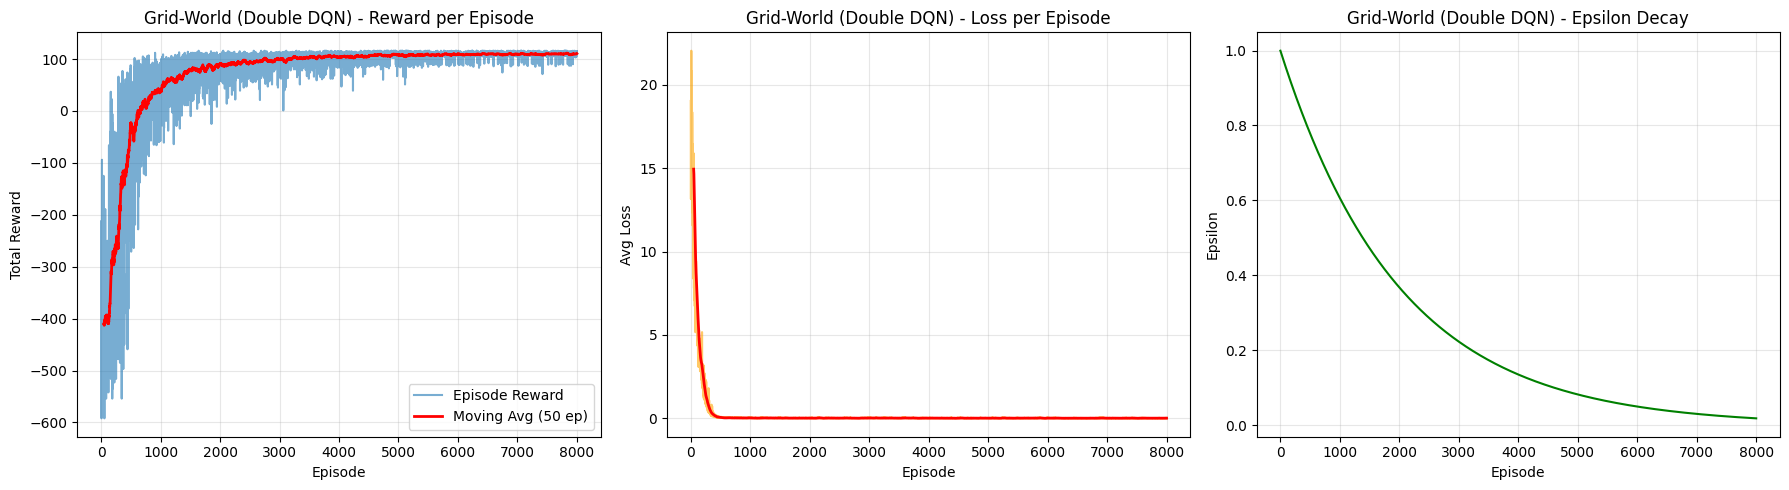

In [9]:
plot_training_results(gw_ddqn_rewards, gw_ddqn_losses, gw_ddqn_epsilons, "Grid-World (Double DQN)")

Eval Episode 1: Total Reward = 113
Eval Episode 2: Total Reward = 110
Eval Episode 3: Total Reward = 110
Eval Episode 4: Total Reward = 111
Eval Episode 5: Total Reward = 112
Eval Episode 6: Total Reward = 112
Eval Episode 7: Total Reward = 109
Eval Episode 8: Total Reward = 110
Eval Episode 9: Total Reward = 108
Eval Episode 10: Total Reward = 110

Avg eval reward over 10 episodes: 110.50


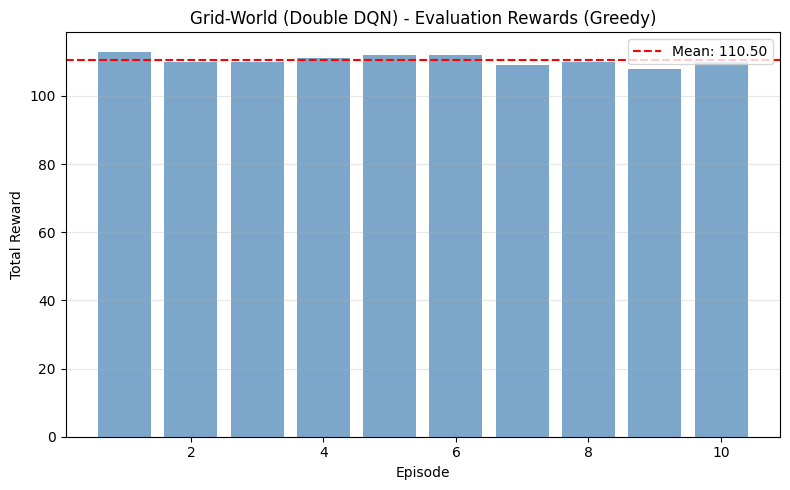

In [10]:
gw_ddqn_eval = evaluate_dqn(gridworld_env, gridworld_ddqn_agent, num_episodes=10, max_steps=200)
plot_eval_results(gw_ddqn_eval, "Grid-World (Double DQN)")

Rendering 1 greedy episode
Step 1: pos=(3, 1, 0), action=0, reward=-1


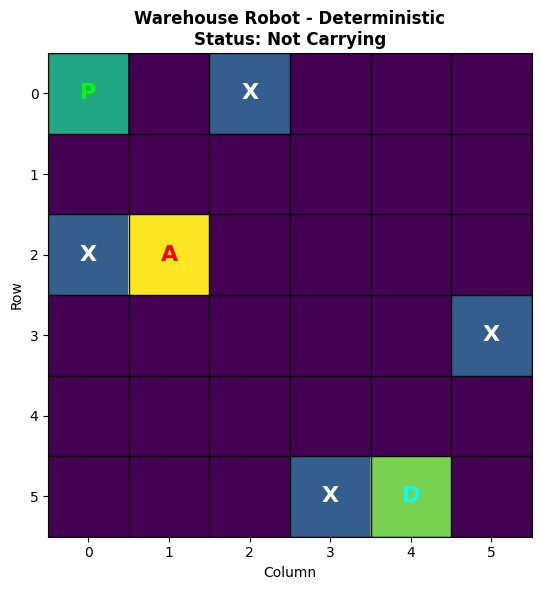

Step 2: pos=(2, 1, 0), action=0, reward=-1


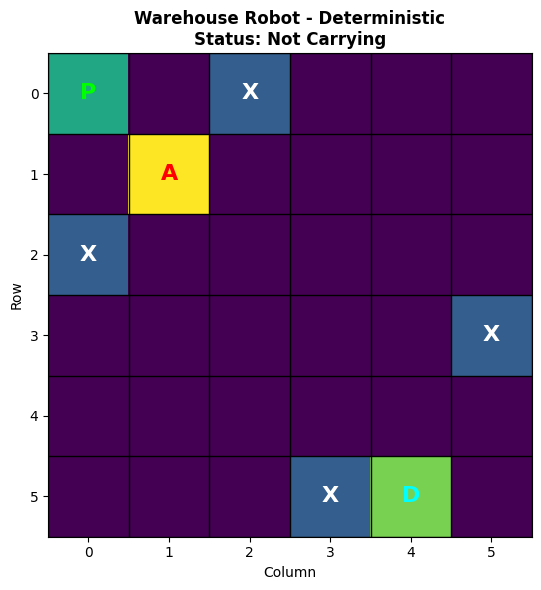

Step 3: pos=(1, 1, 0), action=0, reward=-1


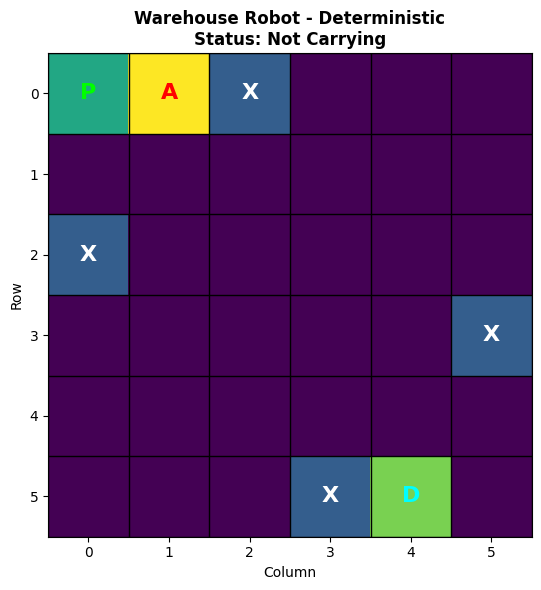

Step 4: pos=(0, 1, 0), action=2, reward=-1


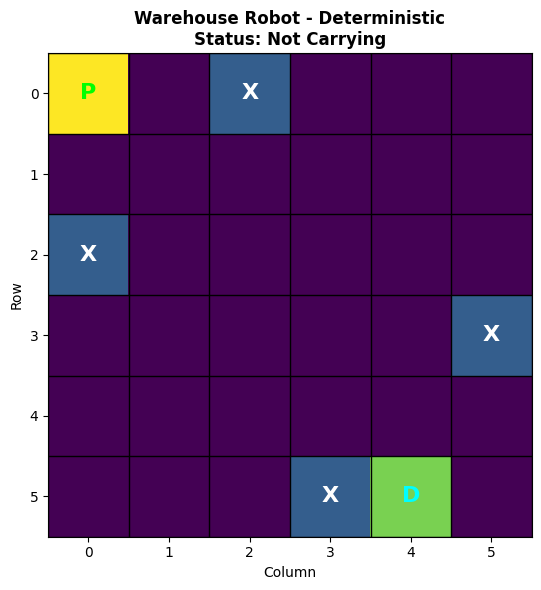

Step 5: pos=(0, 0, 0), action=4, reward=25


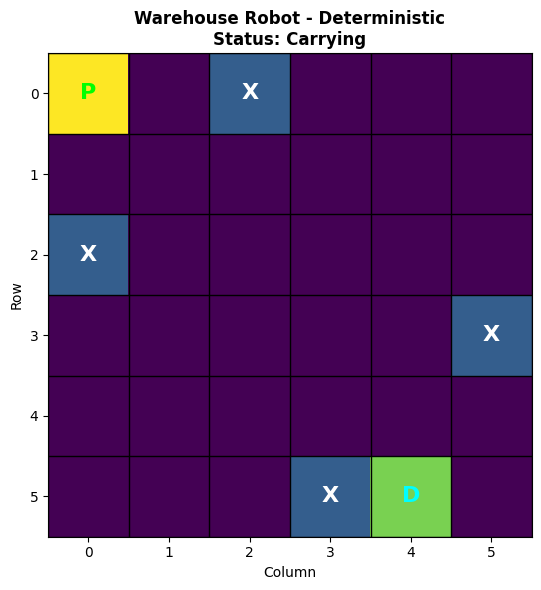

Step 6: pos=(0, 0, 1), action=1, reward=-1


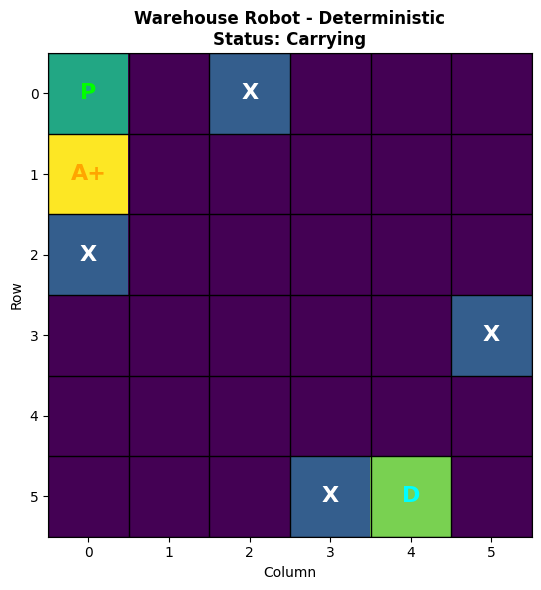

Step 7: pos=(1, 0, 1), action=3, reward=-1


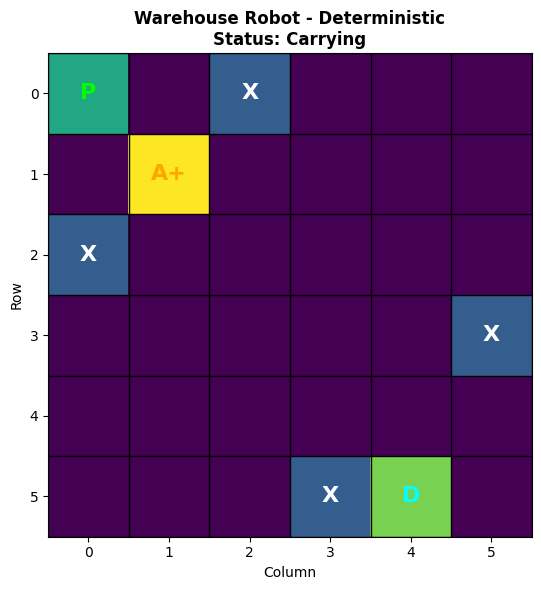

Step 8: pos=(1, 1, 1), action=1, reward=-1


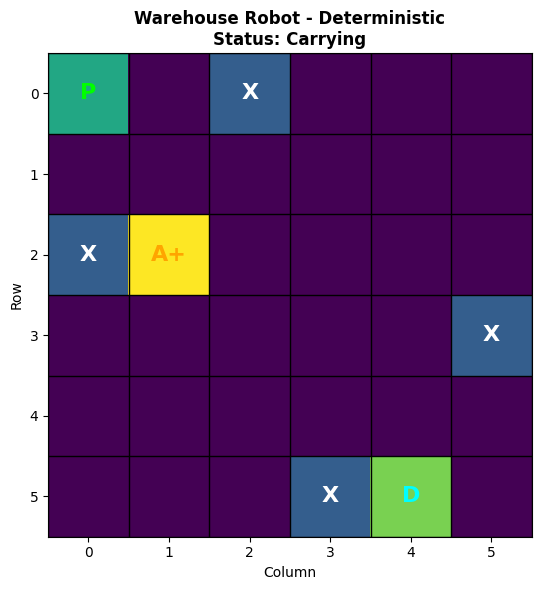

Step 9: pos=(2, 1, 1), action=1, reward=-1


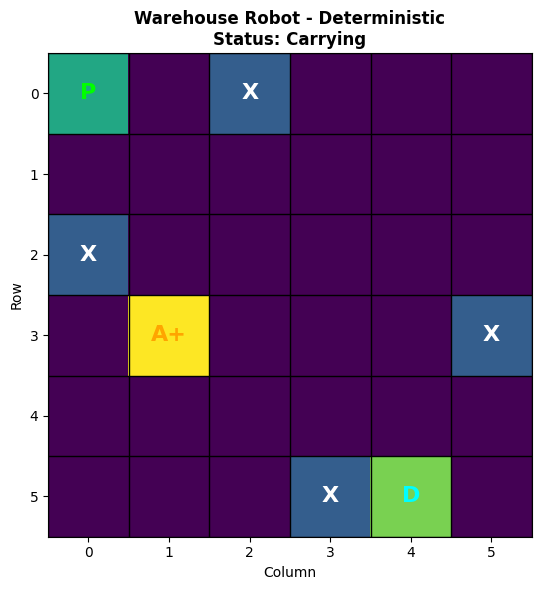

Step 10: pos=(3, 1, 1), action=1, reward=-1


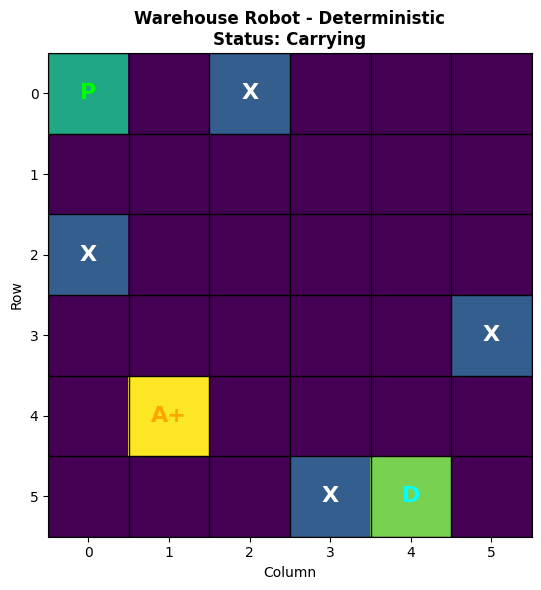

Step 11: pos=(4, 1, 1), action=3, reward=-1


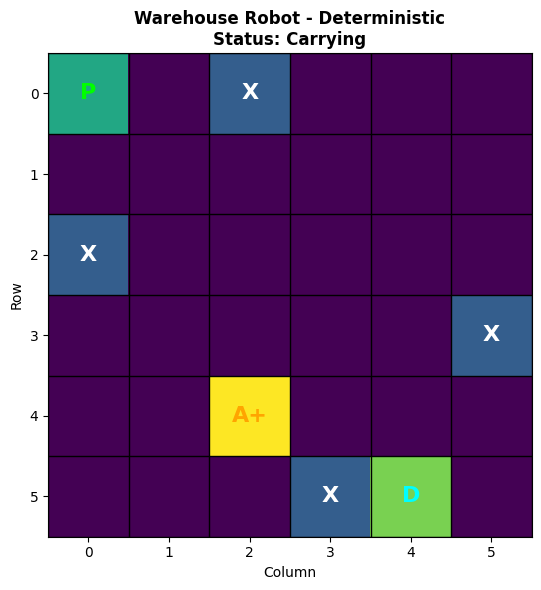

Step 12: pos=(4, 2, 1), action=3, reward=-1


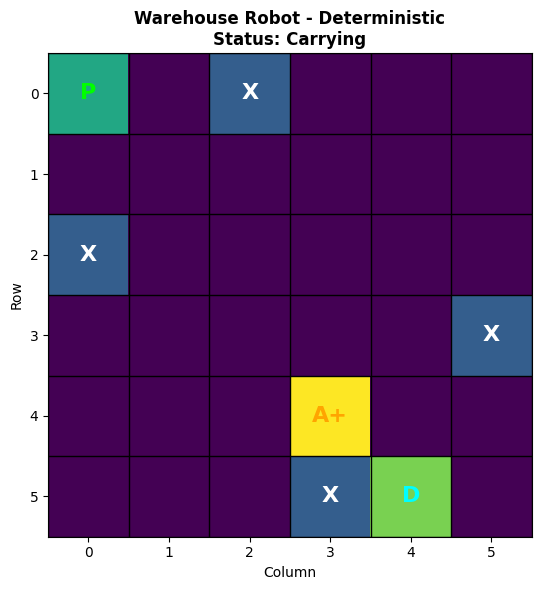

Step 13: pos=(4, 3, 1), action=3, reward=-1


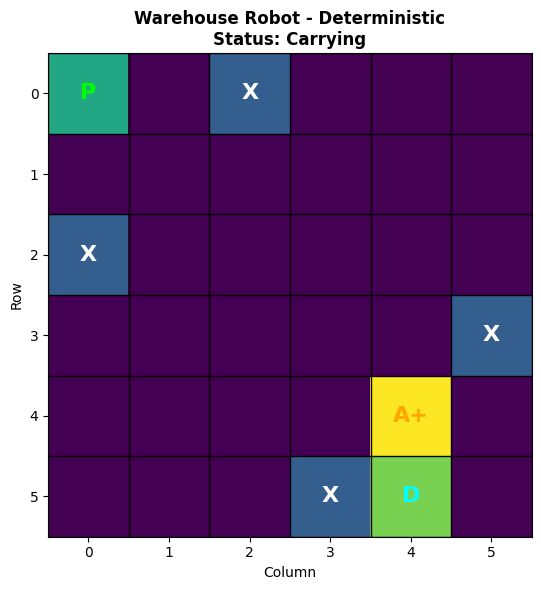

Step 14: pos=(4, 4, 1), action=1, reward=-1


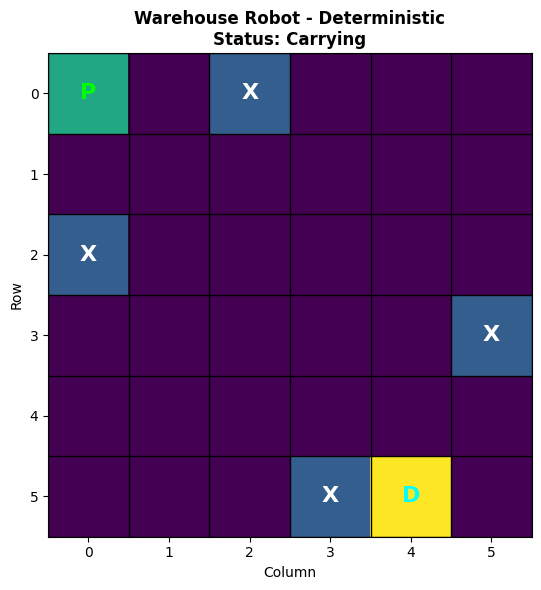

Step 15: pos=(5, 4, 1), action=5, reward=100


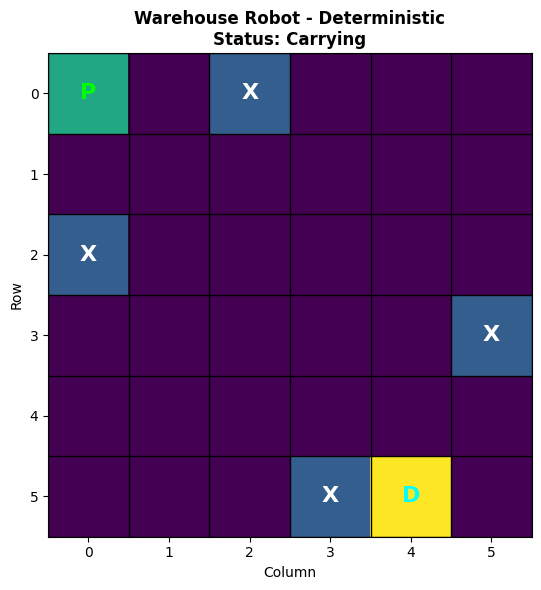

Eval Episode 1: Total Reward = 112

Avg eval reward over 1 episodes: 112.00


In [11]:
print("Rendering 1 greedy episode")
_= evaluate_dqn(gridworld_env, gridworld_ddqn_agent, num_episodes=1, max_steps=200, render=True)

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
torch.save(gridworld_ddqn_agent.q_network.state_dict(),"/content/drive/MyDrive/a2_part_3_ddqn_gridworld_JeetKavaiya_GandharSidhaye.pth")

## 5. Training Double DQN on CartPole-v1

In [14]:
cartpole_env = gym.make("CartPole-v1")
cartpole_ddqn_agent = DoubleDQNAgent(
    state_dim=4, 
    action_dim=2, 
    hidden_dim=32, 
    lr=1e-3,
    gamma=0.99, 
    epsilon_start=1.0, 
    epsilon_end=0.01, 
    epsilon_decay=0.995,
    buffer_size=10000, 
    batch_size=64, 
    target_update_freq=10
)

cp_ddqn_rewards, cp_ddqn_losses, cp_ddqn_epsilons = train_dqn(cartpole_env, cartpole_ddqn_agent, num_episodes=2000, max_steps=500, print_every=500)

Episode 500/2000 | Avg Reward (last 500): 104.77 | Eps: 0.0816 | Loss: 0.6437
Episode 1000/2000 | Avg Reward (last 500): 306.52 | Eps: 0.0100 | Loss: 5.8208
Episode 1500/2000 | Avg Reward (last 500): 267.29 | Eps: 0.0100 | Loss: 9.4516
Episode 2000/2000 | Avg Reward (last 500): 374.83 | Eps: 0.0100 | Loss: 4.6702


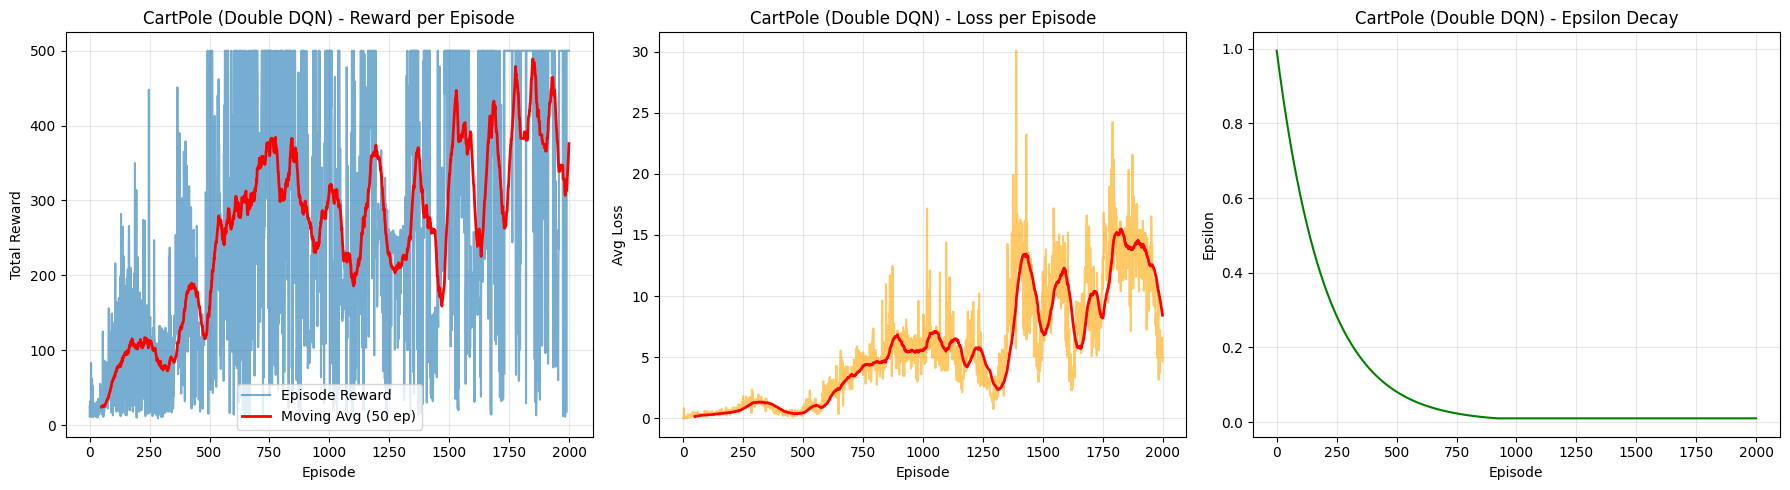

Eval Episode 1: Total Reward = 500.0
Eval Episode 2: Total Reward = 500.0
Eval Episode 3: Total Reward = 500.0
Eval Episode 4: Total Reward = 500.0
Eval Episode 5: Total Reward = 500.0
Eval Episode 6: Total Reward = 500.0
Eval Episode 7: Total Reward = 500.0
Eval Episode 8: Total Reward = 500.0
Eval Episode 9: Total Reward = 500.0
Eval Episode 10: Total Reward = 500.0

Avg eval reward over 10 episodes: 500.00


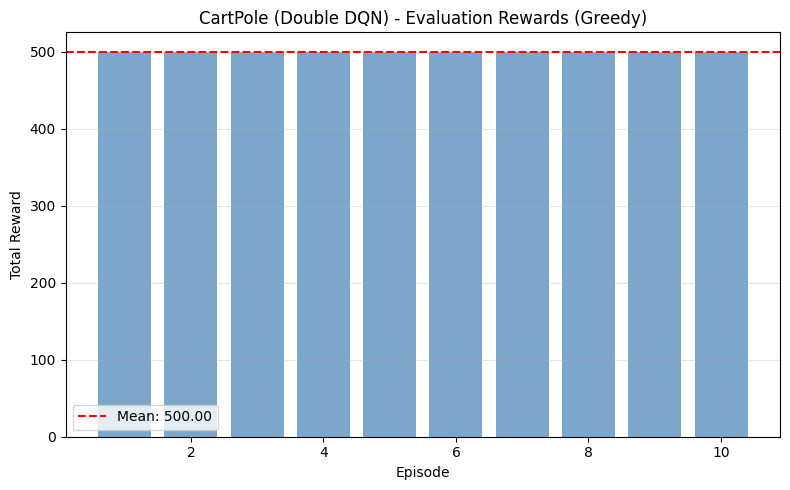

In [15]:
plot_training_results(cp_ddqn_rewards, cp_ddqn_losses, cp_ddqn_epsilons, "CartPole (Double DQN)")
cp_ddqn_eval = evaluate_dqn(cartpole_env, cartpole_ddqn_agent, num_episodes=10, max_steps=500)
plot_eval_results(cp_ddqn_eval, "CartPole (Double DQN)")

In [ ]:
torch.save(cartpole_ddqn_agent.q_network.state_dict(), "/content/drive/MyDrive/a2_part_3_ddqn_cartpole_JeetKavaiya_GandharSidhaye.pth")

## 6. Training Double DQN on MountainCar-v0

In [17]:
def mountaincar_reward_shaper(obs, next_obs, reward, done):
    next_state = np.array(next_obs, dtype=np.float32)
    position = next_state[0]
    velocity = next_state[1]
    shaped = reward + 10 * (abs(velocity))
    if done and position >= 0.5:
        shaped += 100
    return shaped

mc_env = gym.make("MountainCar-v0")
mc_ddqn_agent = DoubleDQNAgent(state_dim=2, action_dim=3, hidden_dim=128, lr=1e-3,
    gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
    buffer_size=20000, batch_size=64, target_update_freq=10)

print("Training Double DQN on MountainCar-v0")
mc_ddqn_rewards, mc_ddqn_losses, mc_ddqn_epsilons = train_dqn(
    mc_env, mc_ddqn_agent, num_episodes=3000, max_steps=200, print_every=500,
    reward_shaper=mountaincar_reward_shaper)

Training Double DQN on MountainCar-v0
Episode 500/3000 | Avg Reward (last 500): -175.62 | Eps: 0.0816 | Loss: 2.1672
Episode 1000/3000 | Avg Reward (last 500): -124.12 | Eps: 0.0100 | Loss: 1.0500
Episode 1500/3000 | Avg Reward (last 500): -104.74 | Eps: 0.0100 | Loss: 0.4357
Episode 2000/3000 | Avg Reward (last 500): -102.65 | Eps: 0.0100 | Loss: 0.3634
Episode 2500/3000 | Avg Reward (last 500): -100.79 | Eps: 0.0100 | Loss: 0.2808
Episode 3000/3000 | Avg Reward (last 500): -106.75 | Eps: 0.0100 | Loss: 0.3654


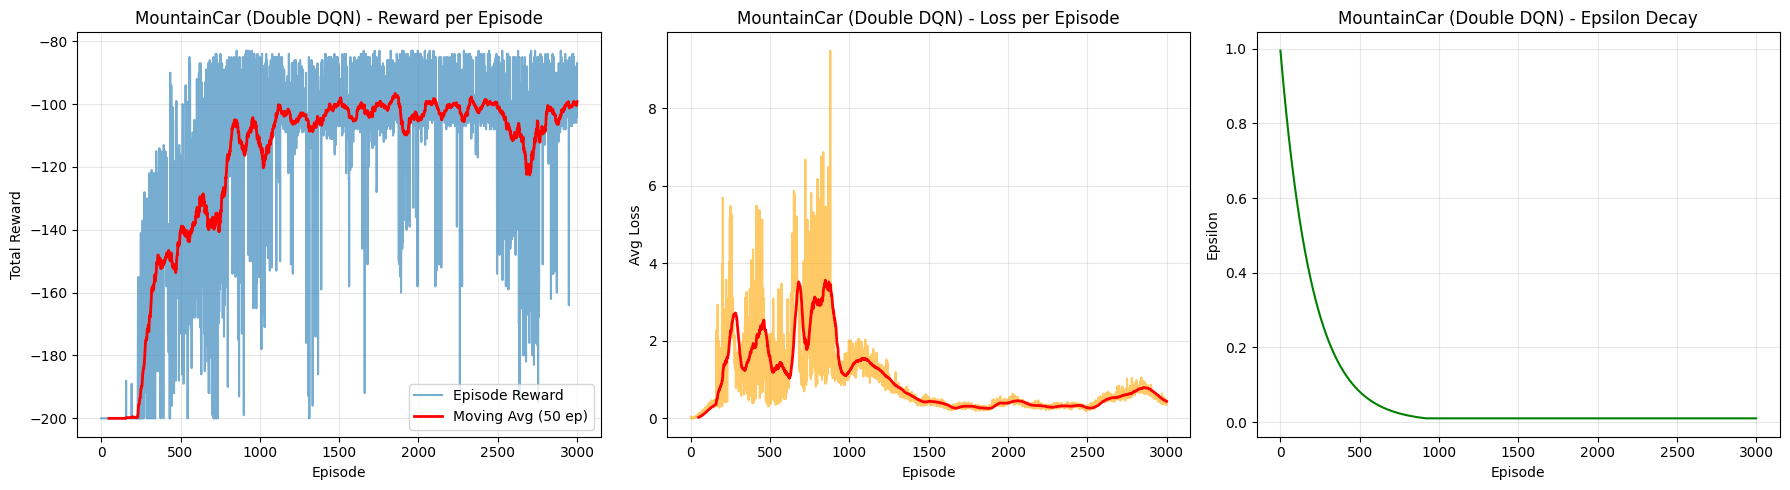

Eval Episode 1: Total Reward = -87.0
Eval Episode 2: Total Reward = -104.0
Eval Episode 3: Total Reward = -104.0
Eval Episode 4: Total Reward = -85.0
Eval Episode 5: Total Reward = -103.0
Eval Episode 6: Total Reward = -103.0
Eval Episode 7: Total Reward = -85.0
Eval Episode 8: Total Reward = -85.0
Eval Episode 9: Total Reward = -102.0
Eval Episode 10: Total Reward = -104.0

Avg eval reward over 10 episodes: -96.20


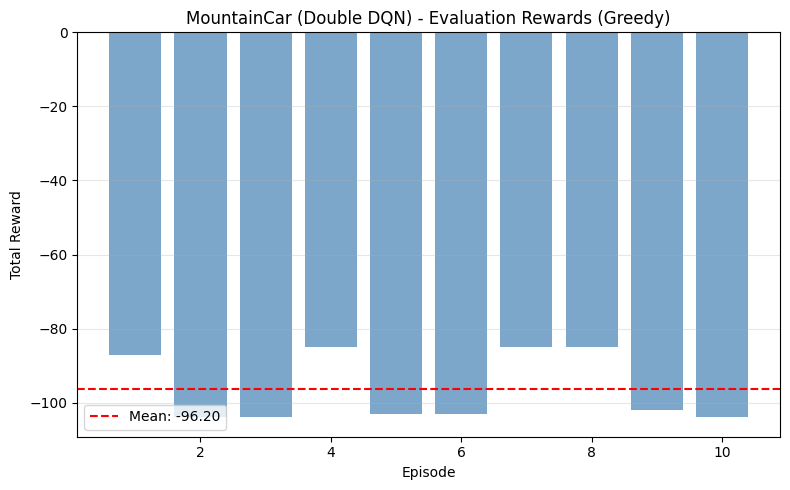

In [18]:
plot_training_results(mc_ddqn_rewards, mc_ddqn_losses, mc_ddqn_epsilons, "MountainCar (Double DQN)")
mc_ddqn_eval = evaluate_dqn(mc_env, mc_ddqn_agent, num_episodes=10, max_steps=200)
plot_eval_results(mc_ddqn_eval, "MountainCar (Double DQN)")

In [ ]:
torch.save(mc_ddqn_agent.q_network.state_dict(), "/content/drive/MyDrive/a2_part_3_ddqn_mountaincar_JeetKavaiya_GandharSidhaye.pth")

## 7. DQN vs Double DQN: Comparison

In [ ]:
class DQNAgent:
    """Vanilla DQN agent (from Part 2) for comparison."""
    def __init__(self, state_dim, action_dim, hidden_dim=64, lr=1e-4,
                gamma=0.99, epsilon_start=1.0, epsilon_end=0.01,
                epsilon_decay=0.995, buffer_size=10000, batch_size=64,
                target_update_freq=10, tau=None):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.tau = tau
        self.q_network = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_network = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.replay_buffer = ReplayBuffer(buffer_size)
        self.steps_done = 0
        self.episodes_done = 0

    def select_action(self, state, greedy=False):
        if greedy or random.random() > self.epsilon:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                return self.q_network(state_t).argmax(dim=1).item()
        return random.randrange(self.action_dim)

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)

    def train_step(self):
        if len(self.replay_buffer) < self.batch_size: return None
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        states_t = torch.FloatTensor(states).to(device)
        actions_t = torch.LongTensor(actions).to(device)
        rewards_t = torch.FloatTensor(rewards).to(device)
        next_states_t = torch.FloatTensor(next_states).to(device)
        dones_t = torch.FloatTensor(dones).to(device)
        curr_q = self.q_network(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)
        
        with torch.no_grad():
            next_q = self.target_network(next_states_t).max(dim=1)[0]
            target_q = rewards_t + self.gamma * next_q * (1 - dones_t)
        loss = self.loss_fn(curr_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        if self.tau is not None:
            for tp, op in zip(self.target_network.parameters(), self.q_network.parameters()):
                tp.data.copy_(self.tau * op.data + (1.0 - self.tau) * tp.data)
        return loss.item()

    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

### Retrain Vanilla DQN for Comparison

In [ ]:
gw_dqn_agent = DQNAgent(state_dim=3, action_dim=6, hidden_dim=64, lr=5e-4,
    gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.9995,
    buffer_size=20000, batch_size=64, target_update_freq=10)
print("Training Vanilla DQN on Grid-World")
gw_dqn_rewards, gw_dqn_losses, gw_dqn_epsilons = train_dqn(gridworld_env, gw_dqn_agent, num_episodes=8000, max_steps=200, print_every=500)

Training Vanilla DQN on Grid-World
Episode 500/8000 | Avg Reward (last 500): -251.50 | Eps: 0.7788 | Loss: 0.0454
Episode 1000/8000 | Avg Reward (last 500): 9.30 | Eps: 0.6065 | Loss: 0.0076
Episode 1500/8000 | Avg Reward (last 500): 60.11 | Eps: 0.4723 | Loss: 0.0082
Episode 2000/8000 | Avg Reward (last 500): 81.32 | Eps: 0.3678 | Loss: 0.0058
Episode 2500/8000 | Avg Reward (last 500): 92.62 | Eps: 0.2864 | Loss: 0.0090
Episode 3000/8000 | Avg Reward (last 500): 96.81 | Eps: 0.2230 | Loss: 0.0054
Episode 3500/8000 | Avg Reward (last 500): 100.38 | Eps: 0.1737 | Loss: 0.0023
Episode 4000/8000 | Avg Reward (last 500): 103.98 | Eps: 0.1353 | Loss: 0.0026
Episode 4500/8000 | Avg Reward (last 500): 105.52 | Eps: 0.1053 | Loss: 0.0165
Episode 5000/8000 | Avg Reward (last 500): 106.92 | Eps: 0.0820 | Loss: 0.0027
Episode 5500/8000 | Avg Reward (last 500): 107.60 | Eps: 0.0639 | Loss: 0.0078
Episode 6000/8000 | Avg Reward (last 500): 108.17 | Eps: 0.0497 | Loss: 0.0017
Episode 6500/8000 | Avg

In [ ]:
cp_dqn_agent = DQNAgent(state_dim=4, action_dim=2, hidden_dim=32, lr=1e-3,
    gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
    buffer_size=10000, batch_size=64, target_update_freq=10)
print("Training Vanilla DQN on CartPole-v1")
cp_dqn_rewards, cp_dqn_losses, cp_dqn_epsilons = train_dqn(cartpole_env, cp_dqn_agent, num_episodes=2000, max_steps=500, print_every=500)

Training Vanilla DQN on CartPole-v1
Episode 500/2000 | Avg Reward (last 500): 137.97 | Eps: 0.0816 | Loss: 1.3122
Episode 1000/2000 | Avg Reward (last 500): 160.75 | Eps: 0.0100 | Loss: 0.8842
Episode 1500/2000 | Avg Reward (last 500): 280.36 | Eps: 0.0100 | Loss: 8.6427
Episode 2000/2000 | Avg Reward (last 500): 302.69 | Eps: 0.0100 | Loss: 18.7245


In [ ]:
mc_dqn_agent = DQNAgent(state_dim=2, action_dim=3, hidden_dim=128, lr=1e-3,
    gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
    buffer_size=20000, batch_size=64, target_update_freq=10)
print("Training Vanilla DQN on MountainCar-v0")
mc_dqn_rewards, mc_dqn_losses, mc_dqn_epsilons = train_dqn(mc_env, mc_dqn_agent, num_episodes=2000, max_steps=200, print_every=500,
reward_shaper=mountaincar_reward_shaper)

Training Vanilla DQN on MountainCar-v0
Episode 500/2000 | Avg Reward (last 500): -180.88 | Eps: 0.0816 | Loss: 2.5966
Episode 1000/2000 | Avg Reward (last 500): -135.24 | Eps: 0.0100 | Loss: 0.9675
Episode 1500/2000 | Avg Reward (last 500): -105.48 | Eps: 0.0100 | Loss: 0.1813
Episode 2000/2000 | Avg Reward (last 500): -109.58 | Eps: 0.0100 | Loss: 0.6865


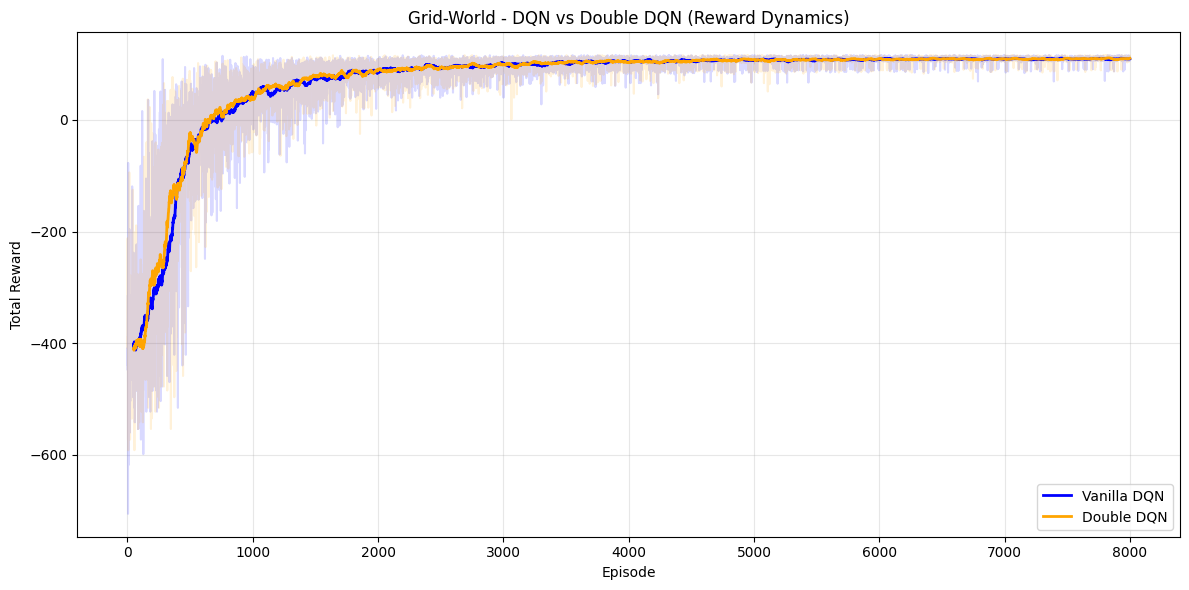

In [24]:
plot_comparison(gw_dqn_rewards, gw_ddqn_rewards, "Grid-World")

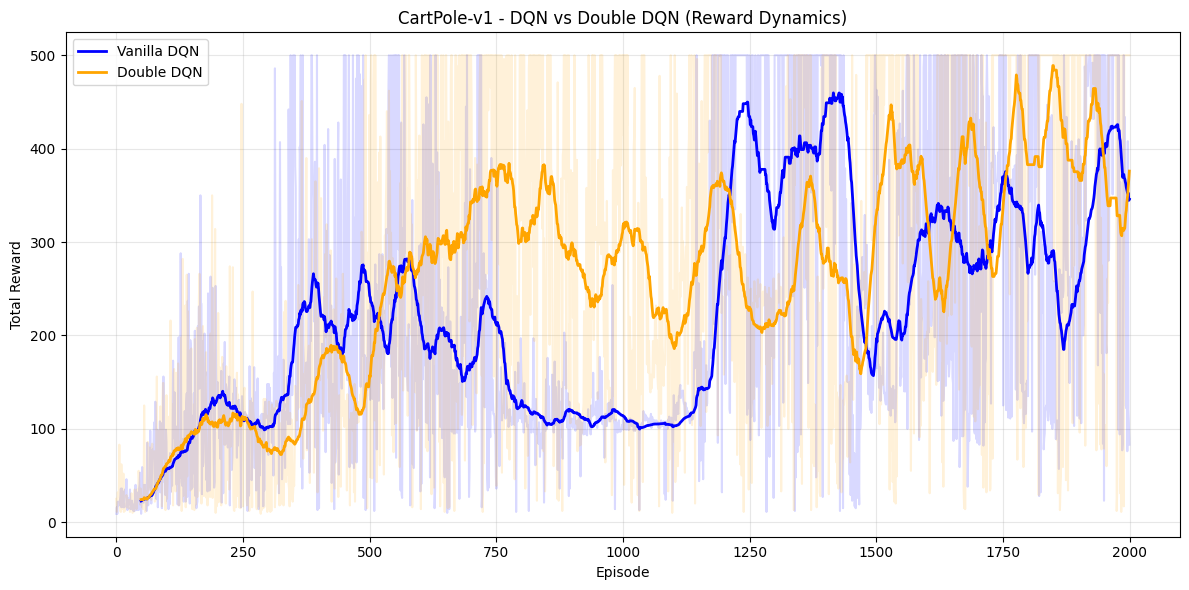

In [25]:
plot_comparison(cp_dqn_rewards, cp_ddqn_rewards, "CartPole-v1")

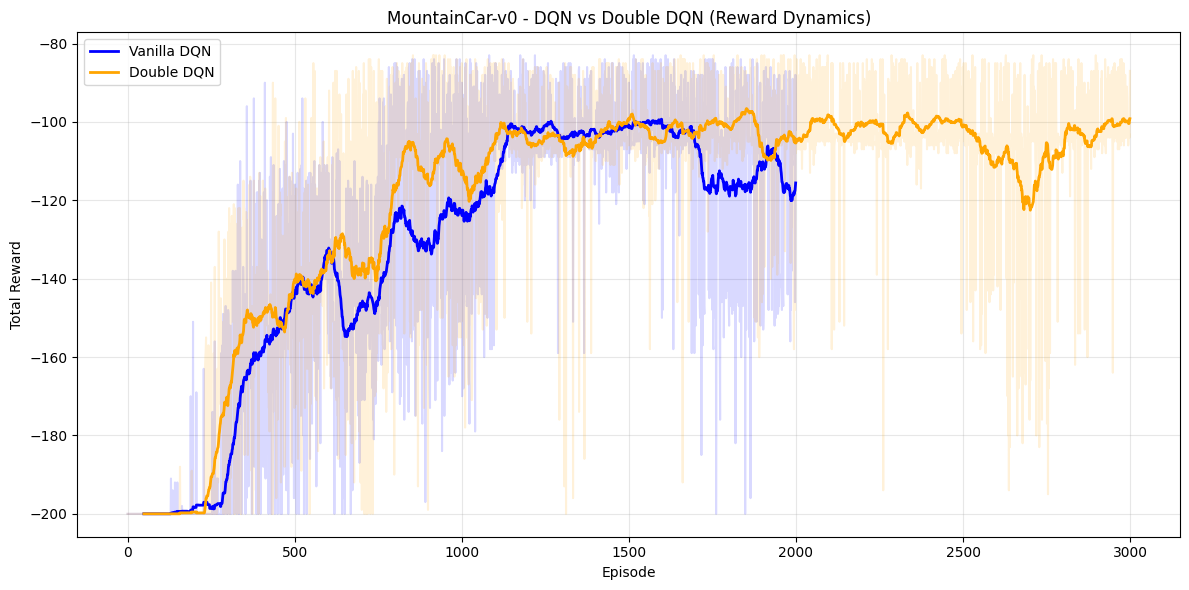

In [26]:
plot_comparison(mc_dqn_rewards, mc_ddqn_rewards, "MountainCar-v0")